<a href="https://colab.research.google.com/github/ThinkingBeyond/BeyondAI-2025/blob/main/Renesh%20Thaipulley%2C%20Arham%20Hussain%20Inamdar%20and%20Sahana%20Dillibabu/MetaCLIP_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install autodistill
!pip install autodistill-metaclip
!pip install roboflow
!pip install matplotlib

In [9]:
import time
start = time.perf_counter()

In [10]:
# DATABASE: https://huggingface.co/datasets/bumbledeep/eyepacs?library=datasets
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("bumbledeep/eyepacs")

training_data = ds["train"]

In [11]:
import warnings
import os
import torch
import numpy as np
import types


warnings.filterwarnings("ignore")
# https://blog.roboflow.com/how-to-use-metaclip/

from autodistill_metaclip import MetaCLIP
from autodistill.detection import CaptionOntology

# The problematic line is inside MetaCLIP's __init__ method in autodistill-metaclip v0.1.3
# It tries to load a pretrained model using a file path that open_clip doesn't recognize as a valid tag or path after deletion.
# The actual tag for this model, as indicated by open_clip's error message, is "metaclip_400m".

# To fix this, we'll patch the MetaCLIP class's __init__ method at runtime to use the correct tag.
import autodistill_metaclip.metaclip_model
import open_clip

def patched_metaclip_init(self, ontology: CaptionOntology):
    HOME = os.path.expanduser('~')
    self.model, _, self.preprocess = open_clip.create_model_and_transforms(
        "ViT-B-32-quickgelu",
        pretrained="metaclip_400m", # This is the fix: use the recognized tag
        cache_dir=os.path.join(HOME, '.cache', 'autodistill', 'open_clip') # Specify cache directory
    )
    self.ontology = ontology
    self.model.eval()

autodistill_metaclip.metaclip_model.MetaCLIP.__init__ = patched_metaclip_init

# The previous code to manually remove the model file is no longer needed
# as open_clip will handle downloading and caching correctly when given a tag.

############################################################################################################
############################################################################################################

############################################################################################################
############################################################################################################



actual_labels = []
predicted_labels = []
confidence_scores = []
confidence_score = []

classes = ["no_diabetic_retinopathy", "mild_diabetic_retinopathy", "moderate_diabetic_retinopathy", "severe_diabetic_retinopathy", "proliferative_diabetic_retinopathy"]

# Final refined ontology descriptions for better distinction between all stages
base_model = MetaCLIP(ontology = CaptionOntology({
    "a healthy retina, free of any lesions, microaneurysms, hemorrhages, or exudates; optic disc and macula appear normal": "no_diabetic_retinopathy",
    "a retina with very few microaneurysms, possibly some minor dot hemorrhages, but no signs of severe damage": "mild_diabetic_retinopathy",
    "A retina with numerous microaneurysms and intraretinal hemorrhages in at least one quadrant, often accompanied by hard exudates and/or cotton wool spots; however, no signs of severe venous beading, IRMA, or neovascularization are present.": "moderate_diabetic_retinopathy",
    "a retina with extensive intraretinal hemorrhages, venous beading, severe intraretinal microvascular abnormalities (IRMA), but without new vessel formation": "severe_diabetic_retinopathy",
    "A retina characterized by the undeniable presence of new, abnormal blood vessels (neovascularization) growing on the optic disc or elsewhere, often with associated vitreous hemorrhage, preretinal hemorrhage, or fibrous proliferation; this is the most advanced and vision-threatening stage.": "proliferative_diabetic_retinopathy"
}))

for i, row in enumerate(training_data):
  try:
    image = row["image"]
    actual_label = row["label"]

    # path = f"/content/image_{i}.jpg"
    # image.save(path)

    results = base_model.predict(image, confidence = 0.00)
    confidence_scores.append(results.confidence)
    confidence_score.append(float(results.confidence.max()))
    # print(f"Confidence scores for each class: {results.confidence}") # Added print statement
    # print(f"type: {type(confidence_scores[0])}")
    # print(f"confidence_scores: {confidence_scores}")
    # print(f"confidence_score: {confidence_score}")
    # print(f"index: {confidence_scores[0].argmax()}")
    predicted = classes[results.confidence.argmax()]
    # print(f"predicted: {predicted}")
    predicted_labels.append(predicted)

    actual_labels.append(actual_label)

    print(i)
  except RecursionError:
    print(f"Recursion Error at image {i}")
    continue

  # if i == 300:
  #   break

Streaming output truncated to the last 5000 lines.
30108
30109
30110
30111
30112
30113
30114
30115
30116
30117
30118
30119
30120
30121
30122
30123
30124
30125
30126
30127
30128
30129
30130
30131
30132
30133
30134
30135
30136
30137
30138
30139
30140
30141
30142
30143
30144
30145
30146
30147
30148
30149
30150
30151
30152
30153
30154
30155
30156
30157
30158
30159
30160
30161
30162
30163
30164
30165
30166
30167
30168
30169
30170
30171
30172
30173
30174
30175
30176
30177
30178
30179
30180
30181
30182
30183
30184
30185
30186
30187
30188
30189
30190
30191
30192
30193
30194
30195
30196
30197
30198
30199
30200
30201
30202
30203
30204
30205
30206
30207
30208
30209
30210
30211
30212
30213
30214
30215
30216
30217
30218
30219
30220
30221
30222
30223
30224
30225
30226
30227
30228
30229
30230
30231
30232
30233
30234
30235
30236
30237
30238
30239
30240
30241
30242
30243
30244
30245
30246
30247
30248
30249
30250
30251
30252
30253
30254
30255
30256
30257
30258
30259
30260
30261
30262
30263
30264
30265
3

In [12]:
end = time.perf_counter()
print(f"{end-start} seconds")

32379.043269327998 seconds


['no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'mild_retinopathy', 'moderate_retinopathy', 'proliferative_retinopathy', 'proliferative_retinopathy', 'no_diabetic_retinopathy', 'mild_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'mild_retinopathy', 'moderate_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'mild_retinopathy', 'no_diabetic_retinopathy', 'moderate_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_diabetic_retinopathy', 'no_di

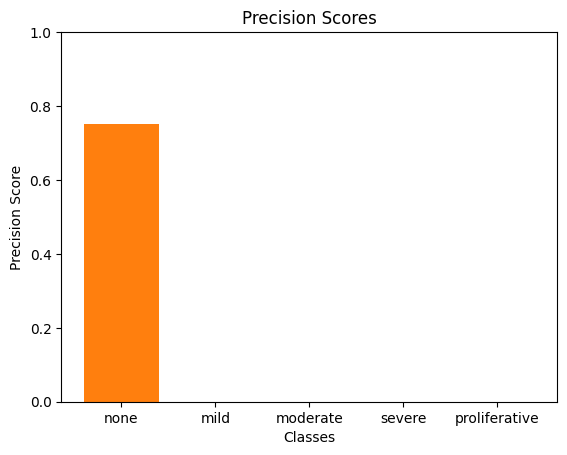

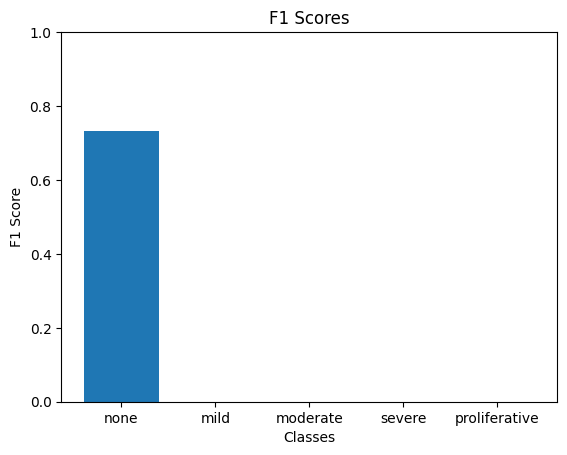

                                    precision    recall  f1-score   support

           no_diabetic_retinopathy       0.75      0.72      0.73     25802
         mild_diabetic_retinopathy       0.00      0.00      0.00         0
     moderate_diabetic_retinopathy       0.00      0.00      0.00         0
       severe_diabetic_retinopathy       0.00      0.00      0.00         0
proliferative_diabetic_retinopathy       0.00      0.00      0.00         0

                         micro avg       0.53      0.72      0.61     25802
                         macro avg       0.15      0.14      0.15     25802
                      weighted avg       0.75      0.72      0.73     25802



In [13]:
!pip install scikit-learn

############################################
# PRECISION, RECALL, AND F1 SCORES

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# print(image_list)
print(actual_labels)
print(predicted_labels)
# print(confidence_score)

class_names = ["none", "mild", "moderate", "severe", "proliferative"]


recall_score_list = recall_score(actual_labels, predicted_labels, labels=classes, average = None).tolist()
plt.bar(class_names, recall_score_list)
plt.title("Recall Scores")
plt.xlabel("Classes")
plt.ylabel("Recall Score")
plt.ylim(0, 1)


precision_score_list = precision_score(actual_labels, predicted_labels, labels=classes, average = None).tolist()
plt.bar(class_names, precision_score_list)
plt.title("Precision Scores")
plt.xlabel("Classes")
plt.ylabel("Precision Score")
plt.ylim(0, 1)
plt.show()


f1_score_list = f1_score(actual_labels, predicted_labels, labels=classes, average=None).tolist()
plt.bar(class_names, f1_score_list)
plt.title("F1 Scores")
plt.xlabel("Classes")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.show()

print(classification_report(actual_labels, predicted_labels, labels=classes))

[24636, 9946, 3, 0, 523]


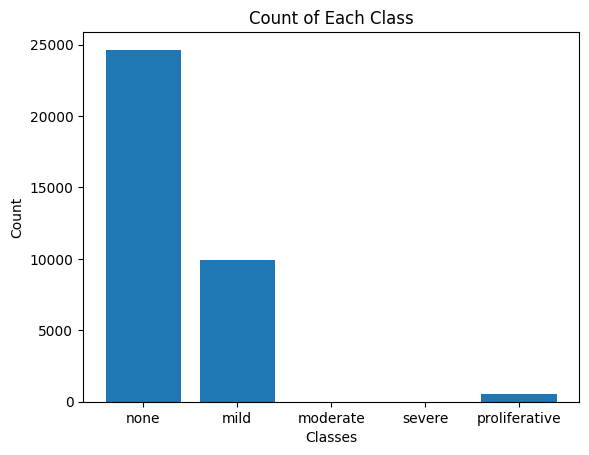

In [14]:
count_dr = [predicted_labels.count("no_diabetic_retinopathy"), predicted_labels.count("mild_diabetic_retinopathy"), predicted_labels.count("moderate_diabetic_retinopathy"), predicted_labels.count("severe_diabetic_retinopathy"), predicted_labels.count("proliferative_diabetic_retinopathy")]

print(count_dr)

plt.bar(class_names, count_dr)
plt.title("Count of Each Class")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()